Models in CSV: <StringArray>
['deepseek-r1-distill-8b']
Length: 1, dtype: str
Plotting layers: [25, 30]


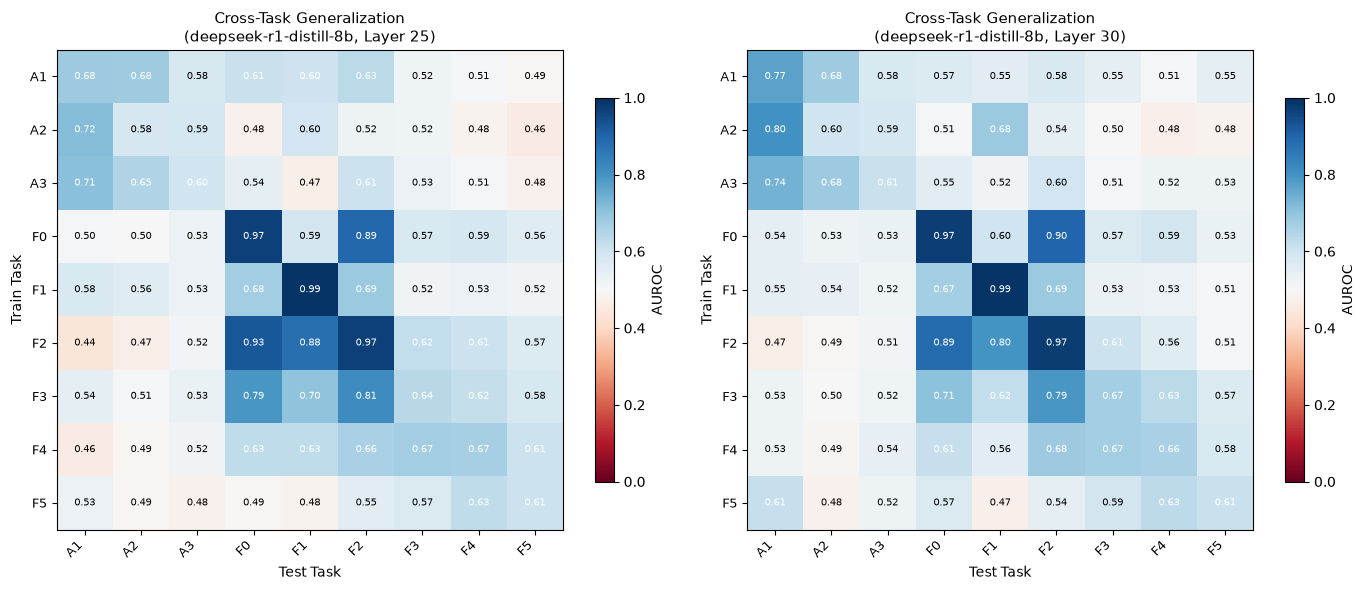

✓ Graph 2 saved: cross_task_generalization.png


In [3]:
import sys
import subprocess
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt

csv_path = "results_database.csv"
df = pd.read_csv(csv_path)

task_order = ["A1", "A2", "A3", "F0", "F1", "F2", "F3", "F4", "F5"]
models = df['model'].unique()
layers_to_plot = [25, 30]

print(f"Models in CSV: {models}")
print(f"Plotting layers: {layers_to_plot}")

fig, axes = plt.subplots(
    len(models), 
    len(layers_to_plot), 
    figsize=(7 * len(layers_to_plot), 6 * len(models))
)

# Handle single model/layer cases
if len(models) == 1 and len(layers_to_plot) == 1:
    axes = [[axes]]
elif len(models) == 1:
    axes = [axes]
elif len(layers_to_plot) == 1:
    axes = [[ax] for ax in axes]

for row_idx, model_name in enumerate(models):
    model_data = df[df['model'] == model_name]
    
    for col_idx, layer in enumerate(layers_to_plot):
        ax = axes[row_idx][col_idx]
        layer_data = model_data[model_data['layer'] == layer]
        
        # Build 9×9 matrix
        n = len(task_order)
        matrix = np.full((n, n), np.nan)
        
        for i, train_task in enumerate(task_order):
            for j, test_task in enumerate(task_order):
                row = layer_data[
                    (layer_data['train_task'] == train_task) & 
                    (layer_data['test_task'] == test_task)
                ]
                if len(row) > 0:
                    matrix[i, j] = row.iloc[0]['auroc']
        
        # Plot heatmap
        im = ax.imshow(matrix, cmap="RdBu", vmin=0, vmax=1, aspect="auto")
        
        # Add text annotations
        for i in range(n):
            for j in range(n):
                if not np.isnan(matrix[i, j]):
                    text_color = "white" if matrix[i, j] > 0.6 else "black"
                    ax.text(j, i, f"{matrix[i, j]:.2f}",
                            ha="center", va="center",
                            color=text_color, fontsize=7)
        
        plt.colorbar(im, ax=ax, label="AUROC", shrink=0.8)
        ax.set_xticks(range(n))
        ax.set_xticklabels(task_order, rotation=45, ha="right", fontsize=9)
        ax.set_yticks(range(n))
        ax.set_yticklabels(task_order, fontsize=9)
        ax.set_xlabel("Test Task", fontsize=10)
        ax.set_ylabel("Train Task", fontsize=10)
        ax.set_title(f"Cross-Task Generalization\n({model_name}, Layer {layer})", fontsize=11)

plt.tight_layout()
plt.savefig("cross_task_generalization.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Graph 2 saved: cross_task_generalization.png")